# Kafka and Spark Streaming Exercise

**INFORMATION**: This exercise is easier on the cluster!

Kafka is an excellent tool for data engineering projects due to its distributed, fault-tolerant, and scalable architecture, which facilitates real-time data streaming and processing. It serves as a highly reliable messaging system that efficiently handles large volumes of data streams from diverse sources. Kafka's ability to decouple data producers from consumers and its support for parallel data processing make it ideal for building robust and scalable data pipelines. Additionally, Kafka's durability and fault-tolerance ensure that data is safely persisted and replicated across nodes, minimizing the risk of data loss and ensuring continuous data availability for downstream applications and analytics.

Spark Streaming enables the real-time processing of data streams with high throughput and low latency. It seamlessly integrates with Apache Spark's core APIs, allowing developers to leverage Spark's powerful data processing capabilities for streaming data. Spark Streaming supports a wide range of data sources, including Kafka, Flume, and HDFS, and can process data in near real-time, making it ideal for applications that require instant insights and timely responses.

Use Python, ```pyspark```, ```pandas```, ```confluent-kafka``` and/or ```kafka-python``` to send messages to a Kafka topic and analyse them with Spark Streaming:

# Kafka

## Import Necessary Libraries

In [1]:
import pandas as pd
import json
import time
from datetime import datetime

from confluent_kafka import Producer

## Load a dataset to stream
Select a suitable dataset from previous exercises and split it into individual JSON messages.

In [2]:
df = pd.read_csv("movies_small.csv")

df = df.drop(columns=["Unnamed: 0"])

df.head()

,User_Id,Movie_Name,Rating,Genre
0,1,Pulp Fiction (1994),5.0,Comedy
1,1,Three Colors: Red (Trois couleurs: Rouge) (1994),3.5,Drama
2,1,Three Colors: Blue (Trois couleurs: Bleu) (1993),5.0,Drama
3,1,Underground (1995),5.0,Comedy
4,1,Singin' in the Rain (1952),3.5,Comedy


## Create a producer and stream the messages
You need to use a Kafka producer to connect to a broker and send the messages to a topic.

In [3]:
conf = {
    "bootstrap.servers": "172.29.16.101:9092"
}

producer = Producer(conf)

topic = "G2-Movies"

In [4]:
producer

In [5]:
first_movie = df.iloc[0].to_dict()

first_movie["timestamp"] = datetime.now().isoformat()

producer.produce(
    topic,
    value=json.dumps(first_movie)
)

producer.flush()

0

## Create a consumer and check if the messages can be read
A Kafka consumer can subscribe to one or more topics and process the messages. Display the messages from the previous step.

In [6]:
from confluent_kafka import Consumer

In [7]:
conf = {
    "bootstrap.servers": "172.29.16.101:9092",
    "group.id": f"verify-{int(time.time())}",
    "auto.offset.reset": "earliest"
}

consumer = Consumer(conf)

consumer.subscribe([topic])

In [8]:
msg = consumer.poll(5.0)

if msg is None:
    print("No message received.")

elif msg.error():
    print(msg.error())

else:
    print(msg.value().decode("utf-8"))

consumer.close()

{"User_Id": 1, "Movie_Name": "Pulp Fiction (1994)", "Rating": 5.0, "Genre": "Comedy", "timestamp": "2026-06-18T20:38:47.253021"}


In [9]:
for _, row in df.iterrows():

    movie = row.to_dict()
    movie["timestamp"] = datetime.now().isoformat()

    producer.produce(
        topic,
        value=json.dumps(movie)
    )

producer.flush()

print("Finished sending dataset.")

Finished sending dataset.


In [10]:
conf = {
    "bootstrap.servers": "172.29.16.101:9092",
    "group.id": f"verify2-{int(time.time())}",
    "auto.offset.reset": "earliest"
}

consumer = Consumer(conf)

consumer.subscribe([topic])

In [11]:
for i in range(5):

    msg = consumer.poll(5.0)

    if msg is None:
        print("No message received.")
        break

    if msg.error():
        print(msg.error())
        break

    print(f"Message {i+1}")
    print(msg.value().decode("utf-8"))
    print("-"*50)

consumer.close()

Message 1
{"User_Id": 1, "Movie_Name": "Pulp Fiction (1994)", "Rating": 5.0, "Genre": "Comedy", "timestamp": "2026-06-18T20:38:47.253021"}
--------------------------------------------------
Message 2
{"User_Id": 1, "Movie_Name": "Pulp Fiction (1994)", "Rating": 5.0, "Genre": "Comedy", "timestamp": "2026-06-18T20:38:55.509589"}
--------------------------------------------------
Message 3
{"User_Id": 1, "Movie_Name": "Three Colors: Red (Trois couleurs: Rouge) (1994)", "Rating": 3.5, "Genre": "Drama", "timestamp": "2026-06-18T20:38:55.509931"}
--------------------------------------------------
Message 4
{"User_Id": 1, "Movie_Name": "Three Colors: Blue (Trois couleurs: Bleu) (1993)", "Rating": 5.0, "Genre": "Drama", "timestamp": "2026-06-18T20:38:55.510115"}
--------------------------------------------------
Message 5
{"User_Id": 1, "Movie_Name": "Underground (1995)", "Rating": 5.0, "Genre": "Comedy", "timestamp": "2026-06-18T20:38:55.510315"}
----------------------------------------------

In [12]:
from confluent_kafka.admin import AdminClient

admin = AdminClient({
    "bootstrap.servers": "172.29.16.101:9092"
})

metadata = admin.list_topics(timeout=10)

print(metadata.topics.keys())

dict_keys(['movies', 'wikimedia-changes', 'music', 'G2-Movies', 'roulette', 'hello-world', '__consumer_offsets', 'stocks', 'bdeng_g1_air_quality_live'])


# Kafka and Spark Streaming
Spark can act as a Kafka consumer. This gives you the benefits of the Spark framework to process the Kafka messages. 

## Spark Context and Session

Initialize Spark Context and Spark Session

In [13]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
        .appName("G2-Movie-Streaming")
        .master("spark://172.29.16.102:7077")
        .getOrCreate()
)

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/18 20:39:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/18 20:39:09 WARN FileSystem: Cannot load filesystem: java.util.ServiceConfigurationError: org.apache.hadoop.fs.FileSystem: com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem Unable to get public no-arg constructor
26/06/18 20:39:09 WARN FileSystem: java.lang.NoClassDefFoundError: com/google/api/client/http/HttpRequestInitializer
26/06/18 20:39:09 WARN FileSystem: java.lang.ClassNotFoundException: com.google.api.client.http.HttpRequestInitializer


## Create a Spark DataFrame from a Kafka stream

In [14]:
movies_stream = (
    spark.readStream
        .format("kafka")
        .option("kafka.bootstrap.servers", "172.29.16.101:9092")
        .option("subscribe", "G2-Movies")
        .option("startingOffsets", "earliest")
        .load()
)

movies_stream.printSchema()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



## Convert the binary Kafka data to strings

In [15]:
from pyspark.sql.functions import col

movies_json = movies_stream.select(
    col("value").cast("string").alias("value")
)

movies_json.printSchema()

root
 |-- value: string (nullable = true)



## Create a structured schema for the streamed data

Use objects like ```StructType```, ```StructField```, ```IntegerType```, ```BooleanType```, etc to create the schema. Afterwards apply the schema to the DataFrame.

In [16]:
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    StringType,
    DoubleType
)

movie_schema = StructType([
    StructField("User_Id", IntegerType(), True),
    StructField("Movie_Name", StringType(), True),
    StructField("Rating", DoubleType(), True),
    StructField("Genre", StringType(), True),
    StructField("timestamp", StringType(), True)
])

In [17]:
from pyspark.sql.functions import from_json

movies = movies_json.select(
    from_json(col("value"), movie_schema).alias("movie")
)

movies = movies.select("movie.*")

movies.printSchema()

root
 |-- User_Id: integer (nullable = true)
 |-- Movie_Name: string (nullable = true)
 |-- Rating: double (nullable = true)
 |-- Genre: string (nullable = true)
 |-- timestamp: string (nullable = true)



## Create a DataFrame grouped by a time window
E.g., the number of messages of the different types over the last minute.

In [18]:
from pyspark.sql.functions import to_timestamp

movies = movies.withColumn(
    "timestamp",
    to_timestamp("timestamp")
)

movies.printSchema()

root
 |-- User_Id: integer (nullable = true)
 |-- Movie_Name: string (nullable = true)
 |-- Rating: double (nullable = true)
 |-- Genre: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)



In [19]:
from pyspark.sql.functions import window, count, avg

movies_grouped = (
    movies
    .groupBy(
        window(col("timestamp"), "1 minute"),
        col("Genre")
    )
    .agg(
        count("*").alias("num_ratings"),
        avg("Rating").alias("avg_rating")
    )
)

## Create a query stream of the DataFrame
Write the output of the DataFrame to a memory sink of your choice. Use the ```start()``` method to actually start the stream processing.

In [20]:
query = (
    movies_grouped
    .writeStream
    .outputMode("complete")
    .format("memory")
    .queryName("movie_ratings")
    .start()
)

26/06/18 20:39:31 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-2ae0daed-df8b-45e2-b736-60fc73e73023. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/06/18 20:39:31 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/06/18 20:39:31 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
                                                                                

In [21]:
spark.sql("""
SELECT *
FROM movie_ratings
""").show(truncate=False)

+------------------------------------------+------------------+-----------+------------------+
|window                                    |Genre             |num_ratings|avg_rating        |
+------------------------------------------+------------------+-----------+------------------+
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Action            |3143       |3.5272033089405026|
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Children          |193        |3.243523316062176 |
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Fantasy           |29         |3.1206896551724137|
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Western           |14         |3.8214285714285716|
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Crime             |631        |3.951664025356577 |
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Film-Noir         |12         |4.0               |
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Romance           |11         |3.1818181818181817|
|{2026-06-18 20:38:00, 2026-06-18 20:39:00}|Advent

## Export the processed data as a Pandas DataFrame and visualize it

In [23]:
result_df = spark.sql("""
SELECT Genre, num_ratings, avg_rating
FROM movie_ratings
ORDER BY num_ratings DESC
""")

pandas_df = result_df.toPandas()

pandas_df.head()

,Genre,num_ratings,avg_rating
0,Action,3143,3.527203
1,Comedy,2377,3.522928
2,Drama,1841,3.730310
3,Adventure,1012,3.635375
4,Crime,631,3.951664


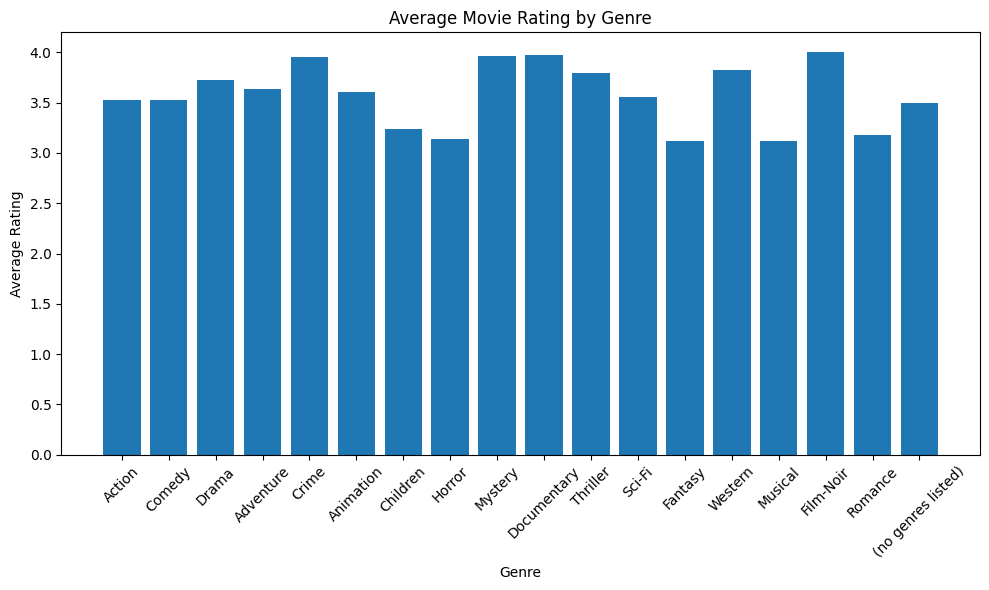

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    pandas_df["Genre"],
    pandas_df["avg_rating"]
)

plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Genre")

plt.tight_layout()
plt.show()